
# TP : Prédire le prix de location de logements à Antananarivo avec une régression linéaire multiple

## 🎯 Objectifs pédagogiques

- Appliquer un pipeline de prétraitement complet sur un jeu de données semi-structuré.
- Gérer les variables qualitatives, les valeurs manquantes, la multicolinéarité et la scalabilité.
- Construire, tester et évaluer un modèle de régression linéaire multiple.
- Déployer le modèle dans une application Python Streamlit avec interface utilisateur.

## 🗂️ Jeu de données

Le jeu de données doit être collecté ou scrappé dans les pages comme Facebook. Il doit comporter les colonnes suivantes :

- `quartier` (catégorielle)
- `superficie` (numérique)
- `nombre_chambres` (numérique)
- `douche_wc` (interieur ou exterieur)
- `type_d_acces` (sans, moto, voiture, voiture_avec_parking)
- `meuble` (booléen : oui ou non)
- `etat_general` (catégorielle : bon, moyen, mauvais)
- `loyer_mensuel` (target)

> ⚠️ Pour ce TP, comme nous n'avons pas de vrai scraping Facebook, nous utilisons un fichier
> `loyers_antananarivo.csv` avec **5 lignes d'exemple** (à toi de le compléter avec de vraies
> données collectées, idéalement 100+ lignes pour un modèle correct). Le contenu du CSV est
> donné à la toute fin de ce notebook, dans la section "Annexe".

## 🧭 Plan du TP

1. **Partie 1** — Préparation des données
2. **Partie 2** — Modélisation (régression linéaire multiple)
3. **Partie 3** — Optimisation du modèle (sélection de variables)
4. **Partie 4** — Déploiement Streamlit



---
## 📦 Étape 0 : Import des librairies

On importe tout ce dont on aura besoin dès le départ :
- `pandas` / `numpy` : manipulation de données
- `matplotlib` / `seaborn` : visualisation
- `sklearn` : prétraitement, modélisation, métriques
- `statsmodels` : régression avec p-values (utile pour la backward elimination et les tests statistiques)
- `joblib` : sauvegarder le modèle entraîné pour le réutiliser dans Streamlit


In [156]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import RFE

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

import joblib

# Pour un affichage plus lisible des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)



---
# 📌 Partie 1 : Préparation des données

Cette partie a pour but de transformer les données brutes (souvent sales, incomplètes,
avec des variables textuelles) en un tableau propre, 100% numérique, exploitable par un
modèle de régression linéaire.



## 1.1 Lecture du dataset brut

On charge le fichier CSV avec `pandas.read_csv`. Place le fichier `loyers_antananarivo.csv`
dans le même dossier que ce notebook (son contenu est donné en Annexe, à la fin).


In [157]:

df = pd.read_csv("../data/loyers_antananarivo.csv")

df.head()


,quartier,superficie,nombre_chambres,douche_wc,type_d_acces,meuble,etat_general,loyer_mensuel
0,Ambaranjana,NaN,NaN,NaN,NaN,oui,bon,1150000.0
1,Ambohipo,73.0,1.0,interieur,NaN,oui,bon,300000.0
2,Analamahitsy,46.0,0.0,interieur,NaN,NaN,moyen,180000.0
3,Cite Planton,101.0,2.0,NaN,voiture_avec_par_parking,oui,bon,3150000.0
4,Ivato,128.0,3.0,NaN,NaN,NaN,mauvais,750000.0


In [158]:

# Informations générales : types de colonnes, nombre de valeurs non-nulles
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   quartier         118 non-null    str    
 1   superficie       114 non-null    float64
 2   nombre_chambres  112 non-null    float64
 3   douche_wc        44 non-null     str    
 4   type_d_acces     50 non-null     str    
 5   meuble           81 non-null     str    
 6   etat_general     118 non-null    str    
 7   loyer_mensuel    118 non-null    float64
dtypes: float64(3), str(5)
memory usage: 7.5 KB


In [159]:

# Statistiques descriptives sur les colonnes numériques
df.describe()


,superficie,nombre_chambres,loyer_mensuel
count,114.000000,112.000000,1.180000e+02
mean,102.960526,2.116071,2.224966e+06
std,36.023600,1.096641,2.511626e+06
min,18.500000,0.000000,1.500000e+05
25%,77.000000,1.000000,5.000000e+05
50%,99.500000,2.000000,1.225000e+06
75%,123.000000,3.000000,3.000000e+06
max,250.000000,6.000000,1.300000e+07



## 1.2 Gestion des valeurs manquantes

Sur un vrai jeu de données scrappé (Facebook, sites d'annonces...), il y aura presque
toujours des valeurs manquantes (NaN). La stratégie dépend du type de colonne :

- **Colonnes numériques** (`superficie`, `nombre_chambres`) → on remplace par la **médiane**
  (plus robuste que la moyenne face aux valeurs extrêmes).
- **Colonnes catégorielles** (`quartier`, `douche_wc`, ...) → on remplace par le **mode**
  (valeur la plus fréquente).

On commence toujours par **compter** les valeurs manquantes pour savoir ce qu'on traite.


In [160]:

# Nombre de valeurs manquantes par colonne
print(df.isnull().sum())


quartier            0
superficie          4
nombre_chambres     6
douche_wc          74
type_d_acces       68
meuble             37
etat_general        0
loyer_mensuel       0
dtype: int64


In [161]:

# Colonnes numériques : imputation par la médiane
colonnes_numeriques = ["superficie", "nombre_chambres"]
for col in colonnes_numeriques:
    df[col] = df[col].fillna(df[col].median())

# Colonnes catégorielles : imputation par le mode (valeur la plus fréquente)
colonnes_categorielles = ["quartier", "douche_wc", "type_d_acces", "meuble", "etat_general"]
for col in colonnes_categorielles:
    df[col] = df[col].fillna(df[col].mode()[0])

# Vérification : il ne doit plus rester de NaN
print(df.isnull().sum())


quartier           0
superficie         0
nombre_chambres    0
douche_wc          0
type_d_acces       0
meuble             0
etat_general       0
loyer_mensuel      0
dtype: int64



## 1.3 Encodage des variables catégorielles

Un modèle de régression linéaire ne comprend que des nombres. Il faut donc encoder les
variables textuelles. On distingue deux cas :

- **Variables nominales** (pas d'ordre logique : `quartier`, `type_d_acces`) →
  **One-Hot Encoding** (`pd.get_dummies`) : une colonne binaire par catégorie.
- **Variables binaires** (`douche_wc`, `meuble`) → simple mapping 0/1.
- **Variables ordinales** (il y a un ordre logique : `etat_general` : mauvais < moyen < bon) →
  mapping manuel en respectant l'ordre, pour que le modèle "comprenne" la hiérarchie.

`drop_first=True` évite le piège de la colinéarité parfaite (dummy variable trap) :
si on connaît toutes les colonnes sauf une, on peut déduire la dernière.


In [ ]:

# Variables binaires -> 0/1
df["douche_wc"] = df["douche_wc"].map({"interieur": 1, "exterieur": 0})
df["meuble"] = df["meuble"].map({"oui": 1, "non": 0})

# Variable ordinale -> encodage respectant l'ordre naturel
ordre_etat = {"mauvais": 0, "moyen": 1, "bon": 2}
df["etat_general"] = df["etat_general"].map(ordre_etat)

# Variables nominales -> One-Hot Encoding
df = pd.get_dummies(df, columns=["quartier", ")"], drop_first=True)

df.head()


,superficie,nombre_chambres,douche_wc,meuble,etat_general,loyer_mensuel,quartier_67Ha,quartier_Alasora,quartier_Ambanidia,quartier_Ambaranjana,...,quartier_Paraky,quartier_Soanierana,quartier_Sud Plast,quartier_Talatamaty,quartier_Tanjombato,quartier_Tsimbazaza,quartier_Vontovorona,type_d_acces_sans,type_d_acces_voiture,type_d_acces_voiture_avec_par_parking
0,99.5,2.0,1,1,2,1150000.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,73.0,1.0,1,1,2,300000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,46.0,0.0,1,1,1,180000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,101.0,2.0,1,1,2,3150000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,128.0,3.0,1,1,0,750000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True



## 1.4 Création de variables dérivées (feature engineering)

Créer de nouvelles variables à partir des existantes peut aider le modèle à mieux capter
la réalité. Exemples classiques pour un prix de location :

- `superficie_par_chambre` : une grande superficie avec beaucoup de chambres n'a pas le
  même "confort par pièce" qu'une petite superficie avec peu de chambres.
- `prix_m2_estime` : indicatif seulement — **attention**, on ne doit JAMAIS créer une variable
  dérivée directement à partir de la cible (`loyer_mensuel`) puis la garder comme feature,
  sinon on fait une fuite de données (data leakage). Ici on l'utilise seulement pour l'exploration,
  pas comme feature d'entraînement.


In [163]:

# Superficie moyenne par chambre (évite la division par zéro avec un petit epsilon)
df["superficie_par_chambre"] = df["superficie"] / df["nombre_chambres"].replace(0, np.nan)
df["superficie_par_chambre"] = df["superficie_par_chambre"].fillna(df["superficie"])

df[["superficie", "nombre_chambres", "superficie_par_chambre"]].head()


,superficie,nombre_chambres,superficie_par_chambre
0,99.5,2.0,49.750000
1,73.0,1.0,73.000000
2,46.0,0.0,46.000000
3,101.0,2.0,50.500000
4,128.0,3.0,42.666667



## 1.5 Détection et suppression des variables fortement corrélées (multicolinéarité)

La régression linéaire multiple suppose que les variables explicatives ne sont pas trop
corrélées entre elles. Deux outils complémentaires :

1. **Matrice de corrélation** (rapide, visuelle) : on repère les paires de variables
   avec une corrélation absolue > 0.8 (règle empirique courante).
2. **VIF (Variance Inflation Factor)** : mesure plus rigoureuse. Un VIF > 5 (parfois 10)
   indique une forte colinéarité pour cette variable avec les autres.

On ne supprime que dans la partie *features* (X), jamais la cible (`loyer_mensuel`).


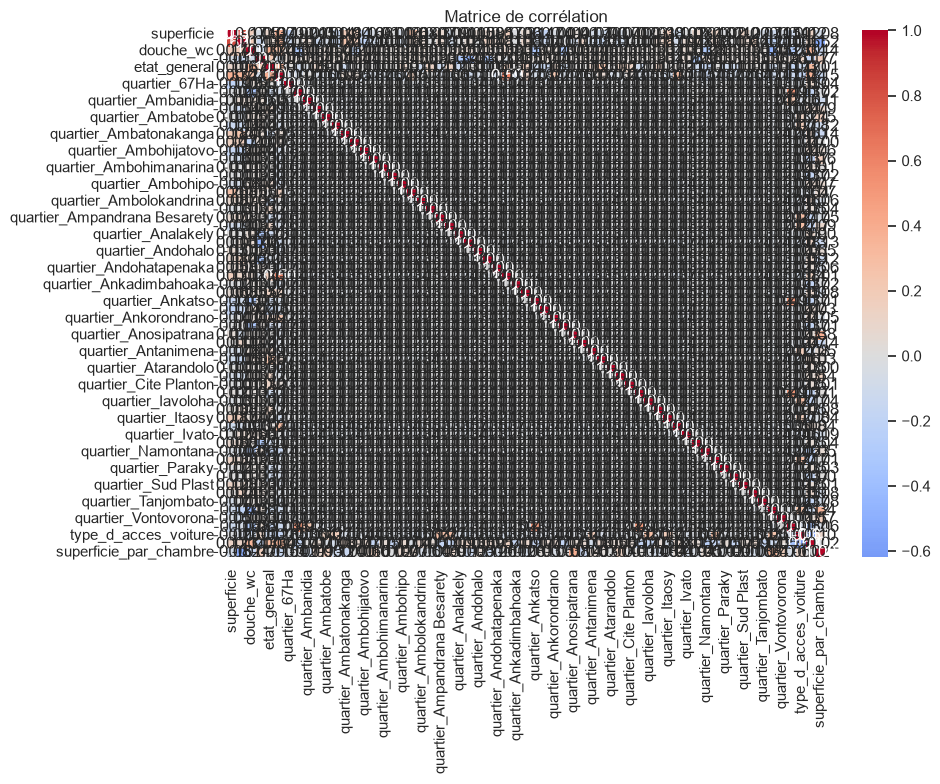

In [ ]:

# Matrice de corrélation (variables numériques uniquement)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


In [165]:

# Séparation features (X) / cible (y)
X = df.drop(columns=["loyer_mensuel"])
y = df["loyer_mensuel"]

# Le VIF n'est fiable que si on a nettement plus de lignes que de colonnes
# (avec seulement quelques lignes d'exemple, la matrice est quasi-singulière : on saute
# le calcul et on prévient l'utilisateur -> à activer une fois un vrai dataset chargé).
if X.shape[0] > X.shape[1] + 5:
    X_const = sm.add_constant(X.astype(float))
    vif_data = pd.DataFrame()
    vif_data["variable"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    vif_data = vif_data[vif_data["variable"] != "const"].sort_values("VIF", ascending=False)
else:
    vif_data = pd.DataFrame(columns=["variable", "VIF"])
    print(f"⚠️ Pas assez de lignes ({X.shape[0]}) par rapport au nombre de variables "
          f"({X.shape[1]}) pour un VIF fiable. Ajoute plus de données pour activer cette étape.")

vif_data


,variable,VIF
2,nombre_chambres,17.355605
1,superficie,13.212046
47,quartier_Ivandry,11.252568
61,type_d_acces_voiture_avec_par_parking,10.857175
29,quartier_Androhibe,9.289599
...,...,...
45,quartier_Ilafy,2.238977
23,quartier_Ampasanimalo,2.147680
22,quartier_Ampandrana Besarety,2.016536
51,quartier_Nanisana,2.014099


In [166]:

# Suppression des variables dont le VIF dépasse le seuil (règle courante : VIF > 10)
# Ne s'applique que si le tableau VIF a pu être calculé ci-dessus.
seuil_vif = 10
variables_a_supprimer = vif_data.loc[vif_data["VIF"] > seuil_vif, "variable"].tolist() if not vif_data.empty else []
print("Variables à supprimer pour multicolinéarité :", variables_a_supprimer)

X = X.drop(columns=variables_a_supprimer, errors="ignore")
X.head()


Variables à supprimer pour multicolinéarité : ['nombre_chambres', 'superficie', 'quartier_Ivandry', 'type_d_acces_voiture_avec_par_parking']


,douche_wc,meuble,etat_general,quartier_67Ha,quartier_Alasora,quartier_Ambanidia,quartier_Ambaranjana,quartier_Ambatobe,quartier_Ambatomainty,quartier_Ambatonakanga,...,quartier_Paraky,quartier_Soanierana,quartier_Sud Plast,quartier_Talatamaty,quartier_Tanjombato,quartier_Tsimbazaza,quartier_Vontovorona,type_d_acces_sans,type_d_acces_voiture,superficie_par_chambre
0,1,1,2,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,49.750000
1,1,1,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,73.000000
2,1,1,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,46.000000
3,1,1,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,50.500000
4,1,1,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,42.666667



## 1.6 Standardisation et normalisation

Les variables numériques (`superficie`, `nombre_chambres`, ...) n'ont pas la même échelle.
La **standardisation** (`StandardScaler`) transforme chaque variable pour qu'elle ait une
moyenne de 0 et un écart-type de 1 : $z = \frac{x - \mu}{\sigma}$.

⚠️ Règle d'or : le `scaler` doit être **entraîné (fit) uniquement sur le train set**, puis
seulement **appliqué (transform)** sur le test set, pour éviter toute fuite d'information.
On le fera donc juste après le split train/test, en Partie 2.



---
# 📌 Partie 2 : Modélisation



## 2.1 Séparation train / test

On garde 80% des données pour l'entraînement et 20% pour l'évaluation (`test_size=0.2`).
`random_state=42` fixe la graine aléatoire pour que le split soit reproductible.

> Avec seulement 5 lignes d'exemple, ce split n'a de sens que comme démonstration :
> en pratique il faut au minimum quelques dizaines/centaines de lignes.


In [167]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille train :", X_train.shape)
print("Taille test  :", X_test.shape)


Taille train : (94, 58)
Taille test  : (24, 58)


In [168]:

# Standardisation : fit uniquement sur le train, puis transform sur train ET test
scaler = StandardScaler()

colonnes_a_standardiser = [c for c in ["superficie", "nombre_chambres", "superficie_par_chambre"] if c in X_train.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colonnes_a_standardiser] = scaler.fit_transform(X_train[colonnes_a_standardiser])
X_test_scaled[colonnes_a_standardiser] = scaler.transform(X_test[colonnes_a_standardiser])

X_train_scaled.head()


,douche_wc,meuble,etat_general,quartier_67Ha,quartier_Alasora,quartier_Ambanidia,quartier_Ambaranjana,quartier_Ambatobe,quartier_Ambatomainty,quartier_Ambatonakanga,...,quartier_Paraky,quartier_Soanierana,quartier_Sud Plast,quartier_Talatamaty,quartier_Tanjombato,quartier_Tsimbazaza,quartier_Vontovorona,type_d_acces_sans,type_d_acces_voiture,superficie_par_chambre
44,1,1,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,-0.113948
12,1,0,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.130048
15,1,1,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.364792
70,1,1,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.042376
107,1,1,2,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.174014



## 2.2 Implémentation de la régression linéaire multiple

On utilise `LinearRegression` de scikit-learn, qui trouve les coefficients $\beta_i$
minimisant la somme des carrés des résidus :

$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n $$


In [169]:

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Coefficients associés à chaque variable
coefficients = pd.Series(model.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)
print("Intercept (beta0) :", model.intercept_)
coefficients


Intercept (beta0) : 6669231.686419249


quartier_Analamahitsy          -6.202565e+06
quartier_Mandroseza            -6.118627e+06
quartier_Tanjombato            -4.374713e+06
quartier_Andoharanofotsy       -4.336476e+06
quartier_Ankadimbahoaka        -4.294544e+06
quartier_Ambohipo              -4.240245e+06
quartier_Ilafy                 -4.136058e+06
quartier_Ambohimangakely       -4.111663e+06
quartier_Talatamaty            -4.045310e+06
quartier_Atarandolo            -3.917821e+06
quartier_Andohalo              -3.848612e+06
quartier_Sud Plast             -3.800702e+06
quartier_Ambohimanarina        -3.773979e+06
quartier_Ambatomainty          -3.704072e+06
quartier_67Ha                  -3.680570e+06
quartier_Itaosy                -3.639247e+06
quartier_Androhibe              3.451033e+06
quartier_Paraky                -3.443200e+06
quartier_Ambohimanambola       -3.421155e+06
quartier_Vontovorona           -3.399234e+06
quartier_Analakely             -3.395493e+06
quartier_Soanierana            -3.363595e+06
quartier_A


## 2.3 Évaluation : R² et RMSE

- **R² (coefficient de détermination)** : proportion de la variance du loyer expliquée
  par le modèle. Proche de 1 = très bon, proche de 0 = mauvais.
- **RMSE (Root Mean Squared Error)** : erreur moyenne du modèle, dans la même unité
  que la cible (ici en Ariary). Plus c'est petit, mieux c'est.


In [170]:

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

r2_train = r2_score(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Train -> R² : {r2_train:.3f} | RMSE : {rmse_train:,.0f} Ar")
print(f"Test  -> R² : {r2_test:.3f} | RMSE : {rmse_test:,.0f} Ar")


Train -> R² : 0.825 | RMSE : 1,053,114 Ar
Test  -> R² : 0.025 | RMSE : 2,347,541 Ar



## 2.4 Vérification des hypothèses de la régression linéaire multiple

Une régression linéaire n'est fiable que si certaines hypothèses sur les **résidus**
(erreurs = y_réel - y_prédit) sont respectées :

1. **Linéarité** : les résidus doivent être centrés autour de 0, sans motif particulier
   quand on les trace contre les prédictions.
2. **Homoscédasticité** : la variance des résidus doit être constante (pas en forme
   d'entonnoir sur le graphique résidus vs prédictions).
3. **Normalité des résidus** : vérifiée avec un QQ-plot (les points doivent suivre la
   diagonale) et/ou le test de Shapiro-Wilk.
4. **Indépendance des résidus** : vérifiée avec le test de **Durbin-Watson**
   (valeur proche de 2 = pas d'autocorrélation).


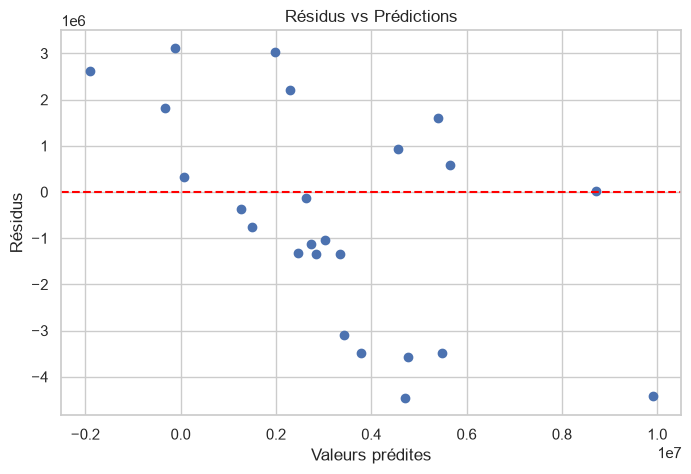

In [171]:

residus = y_test - y_pred_test

# 1 & 2 : Résidus vs valeurs prédites (linéarité + homoscédasticité)
plt.figure()
plt.scatter(y_pred_test, residus)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.show()


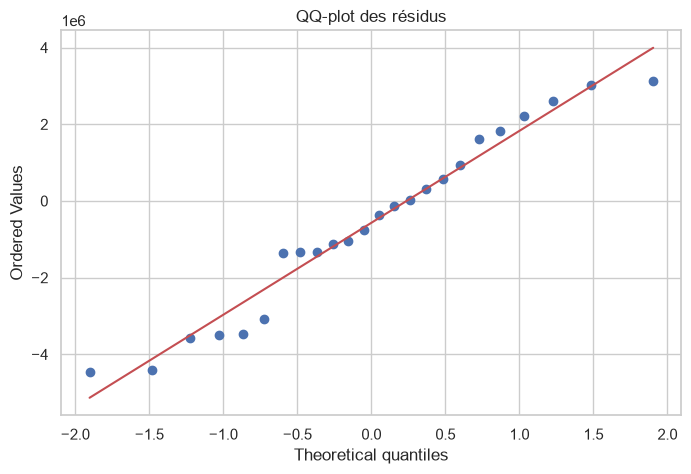

Shapiro-Wilk : statistique=0.952, p-value=0.300
-> Résidus considérés normaux


In [172]:

# 3 : QQ-plot pour vérifier la normalité des résidus
plt.figure()
stats.probplot(residus, dist="norm", plot=plt)
plt.title("QQ-plot des résidus")
plt.show()

# Test de Shapiro-Wilk (H0 : les résidus suivent une loi normale)
if len(residus) >= 3:
    shapiro_stat, shapiro_p = stats.shapiro(residus)
    print(f"Shapiro-Wilk : statistique={shapiro_stat:.3f}, p-value={shapiro_p:.3f}")
    print("-> Résidus considérés normaux" if shapiro_p > 0.05 else "-> Résidus probablement non-normaux")


In [173]:

# 4 : Test de Durbin-Watson (indépendance des résidus). Valeur ~2 = idéal.
dw = durbin_watson(residus)
print(f"Durbin-Watson : {dw:.3f}")


Durbin-Watson : 1.604



---
# 📌 Partie 3 : Optimisation du modèle

Objectif : ne garder que les variables réellement utiles, pour un modèle plus simple,
plus interprétable et souvent plus performant en généralisation.



## 3.1 Backward Elimination (élimination récursive manuelle par p-value)

Principe :
1. On entraîne un modèle OLS (`statsmodels`) avec **toutes** les variables.
2. On regarde la p-value de chaque variable (test de significativité : H0 = le
   coefficient est nul, donc la variable n'a pas d'effet réel).
3. On retire la variable avec la **p-value la plus élevée** si elle dépasse un seuil
   (généralement 0.05).
4. On recommence jusqu'à ce que toutes les variables restantes soient significatives.


In [174]:

def backward_elimination(X, y, seuil=0.05):
    X = sm.add_constant(X.astype(float))
    while X.shape[1] > 1:
        # OLS a besoin de strictement plus d'observations que de variables (sinon système
        # sous-déterminé) : avec un tout petit dataset d'exemple, on s'arrête plus tôt.
        if X.shape[0] <= X.shape[1]:
            print("⚠️ Pas assez de lignes pour poursuivre l'élimination (n <= nb variables). Arrêt.")
            break
        model_ols = sm.OLS(y, X).fit()
        p_values = model_ols.pvalues.drop("const", errors="ignore")
        pire_p = p_values.max() if not p_values.empty else 0
        if pire_p > seuil:
            variable_a_retirer = p_values.idxmax()
            X = X.drop(columns=[variable_a_retirer])
            print(f"Suppression de '{variable_a_retirer}' (p-value = {pire_p:.3f})")
        else:
            break
    return model_ols, X.drop(columns=["const"], errors="ignore")

if X_train_scaled.shape[0] > X_train_scaled.shape[1] + 1:
    model_final_ols, X_selection_backward = backward_elimination(X_train_scaled, y_train)
    print("\nVariables conservées :", list(X_selection_backward.columns))
    print(model_final_ols.summary())
else:
    print("⚠️ Trop peu de lignes d'entraînement par rapport au nombre de variables pour une "
          "backward elimination fiable avec ce jeu d'exemple. Ajoute plus de données réelles "
          "pour activer cette étape (la logique du code reste valable telle quelle).")


Suppression de 'quartier_Faravohitra' (p-value = 0.971)
Suppression de 'douche_wc' (p-value = 0.965)
Suppression de 'quartier_Ambohijanahary' (p-value = 0.866)
Suppression de 'quartier_Ambohitrarahaba' (p-value = 0.856)
Suppression de 'quartier_Ambondrona' (p-value = 0.850)
Suppression de 'quartier_By Pass' (p-value = 0.733)
Suppression de 'quartier_Alasora' (p-value = 0.701)
Suppression de 'quartier_Ankatso' (p-value = 0.771)
Suppression de 'quartier_Ankorondrano' (p-value = 0.561)
Suppression de 'quartier_Andohatapenaka' (p-value = 0.858)
Suppression de 'quartier_Ampandrana Besarety' (p-value = 0.260)
Suppression de 'quartier_Nanisana' (p-value = 0.232)
Suppression de 'quartier_Iavoloha' (p-value = 0.293)
Suppression de 'quartier_Ankadivato' (p-value = 0.273)
Suppression de 'superficie_par_chambre' (p-value = 0.318)
Suppression de 'quartier_Ambatonakanga' (p-value = 0.409)
Suppression de 'quartier_Ambanidia' (p-value = 0.411)
Suppression de 'quartier_Cite Planton' (p-value = 0.282)
S


## 3.2 RFE (Recursive Feature Elimination)

`RFE` de scikit-learn entraîne le modèle, retire la variable la moins importante
(plus petit coefficient en valeur absolue), et répète jusqu'à atteindre le nombre de
variables souhaité (`n_features_to_select`). C'est une approche automatique, complémentaire
à la backward elimination.


In [175]:

n_features_cible = min(5, X_train_scaled.shape[1], max(1, X_train_scaled.shape[0] - 1))  # à ajuster selon ton dataset

rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_features_cible)
rfe.fit(X_train_scaled, y_train)

variables_selectionnees_rfe = X_train_scaled.columns[rfe.support_].tolist()
print("Variables sélectionnées par RFE :", variables_selectionnees_rfe)

# Réentraînement du modèle final avec seulement ces variables
model_optimise = LinearRegression()
model_optimise.fit(X_train_scaled[variables_selectionnees_rfe], y_train)

y_pred_optimise = model_optimise.predict(X_test_scaled[variables_selectionnees_rfe])
print("R² (modèle optimisé) :", r2_score(y_test, y_pred_optimise))
print("RMSE (modèle optimisé) :", np.sqrt(mean_squared_error(y_test, y_pred_optimise)))


Variables sélectionnées par RFE : ['meuble', 'quartier_Analamahitsy', 'quartier_Androhibe', 'quartier_Ankorondrano', 'quartier_Mandroseza']
R² (modèle optimisé) : 0.010696059249893364
RMSE (modèle optimisé) : 2364425.368631274


In [176]:

# Sauvegarde du modèle final + du scaler + de la liste des colonnes attendues
# (indispensable pour les réutiliser tels quels dans l'application Streamlit)
joblib.dump(model_optimise, "./streamlit/model.pkl")
joblib.dump(scaler, "./streamlit/scaler.pkl")
joblib.dump(variables_selectionnees_rfe, "./streamlit/colonnes_modele.pkl")
joblib.dump(colonnes_a_standardiser, "./streamlit/colonnes_a_standardiser.pkl")
print("Modèle et objets de prétraitement sauvegardés.")


Modèle et objets de prétraitement sauvegardés.



---
# 📌 Partie 4 : Déploiement d'une application Streamlit

On crée un fichier séparé `app.py` (Streamlit ne s'exécute pas dans un notebook, il se
lance avec `streamlit run app.py` dans un terminal). La commande magique `%%writefile`
ci-dessous écrit directement le code dans un fichier `app.py` à côté du notebook.

L'application doit :
1. Charger le modèle et le scaler sauvegardés (`model.pkl`, `scaler.pkl`).
2. Proposer un formulaire de saisie (quartier, superficie, nombre de chambres, ...).
3. Reproduire **exactement** le même prétraitement que dans le notebook (encodage,
   standardisation) avant de prédire, sinon la prédiction sera fausse.
4. Afficher le loyer prédit et un graphique des poids (coefficients) des variables.
5. (Bonus) Afficher une carte interactive avec `folium` pour visualiser le quartier.


In [177]:
%%writefile streamlit/app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --- Chargement du modèle et des objets de prétraitement ---
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
colonnes_modele = joblib.load("colonnes_modele.pkl")
colonnes_a_standardiser = joblib.load("colonnes_a_standardiser.pkl")

st.set_page_config(page_title="Prédiction de loyer - Antananarivo", page_icon="🏠")
st.title("🏠 Prédiction du loyer mensuel à Antananarivo")
st.write("Renseigne les caractéristiques du logement pour estimer son loyer mensuel.")

# --- Formulaire de saisie utilisateur ---
quartier = st.selectbox(
    "Quartier",
    [
        "67 Ha",
        "Alakamisy Fenoarivo",
        "Alarobia",
        "Ambanidia",
        "Ambatobe",
        "Ambatoroka",
        "Ambodivona",
        "Ambohidahy",
        "Ambohimanga",
        "Ambohimangakely",
        "Ambohijatovo",
        "Ambohipo",
        "Ampefiloha",
        "Ampandrana",
        "Ampasampito",
        "Ampitatafika",
        "Analakely",
        "Andavamamba",
        "Andohalo",
        "Andraharo",
        "Andravoahangy",
        "Anjeva",
        "Ankadifotsy",
        "Ankadikely Ilafy",
        "Ankadimbahoaka",
        "Ankadivato",
        "Ankazomanga",
        "Ankorondrano",
        "Anosibe",
        "Anosy",
        "Anosy Avaratra",
        "Antanimena",
        "Antsahabe",
        "Antsakaviro",
        "By-Pass",
        "Faravohitra",
        "Ilafy",
        "Isotry",
        "Itaosy",
        "Ivandry",
        "Mahamasina",
        "Mandroseza",
        "Namontana",
        "Sabotsy Namehana",
        "Soanierana",
        "Talatamaty",
        "Tanjombato",
        "Tsaralalàna",
    ],
)
superficie = st.number_input("Superficie (m²)", min_value=5, max_value=500, value=40)
nombre_chambres = st.number_input("Nombre de chambres", min_value=1, max_value=10, value=2)
douche_wc = st.radio("Douche / WC", ["interieur", "exterieur"])
type_d_acces = st.selectbox("Type d'accès", ["sans", "moto", "voiture", "voiture_avec_parking"])
meuble = st.radio("Meublé ?", ["oui", "non"])
etat_general = st.selectbox("État général", ["mauvais", "moyen", "bon"])

if st.button("Prédire le loyer"):
    # --- Reconstruction d'une ligne avec le MÊME prétraitement que dans le notebook ---
    ligne = pd.DataFrame([{
        "superficie": superficie,
        "nombre_chambres": nombre_chambres,
        "douche_wc": 1 if douche_wc == "interieur" else 0,
        "meuble": 1 if meuble == "oui" else 0,
        "etat_general": {"mauvais": 0, "moyen": 1, "bon": 2}[etat_general],
        "superficie_par_chambre": superficie / nombre_chambres,
    }])

    # One-hot encoding manuel pour quartier / type_d_acces (mêmes colonnes qu'à l'entraînement)
    for col in colonnes_modele:
        if col.startswith("quartier_"):
            ligne[col] = 1 if col == f"quartier_{quartier}" else 0
        elif col.startswith("type_d_acces_"):
            ligne[col] = 1 if col == f"type_d_acces_{type_d_acces}" else 0

    # --- Standardisation AVANT de restreindre aux colonnes du modèle ---
    # Important : si la RFE a éliminé "superficie", "nombre_chambres" ou
    # "superficie_par_chambre", ces colonnes n'existent plus dans `colonnes_modele`.
    # On ne peut donc standardiser que celles qui sont réellement présentes dans `ligne`.
    colonnes_a_standardiser_presentes = [c for c in colonnes_a_standardiser if c in ligne.columns]

    if colonnes_a_standardiser_presentes:
        # scaler a été entraîné (fit) sur la liste complète colonnes_a_standardiser, dans cet
        # ordre précis. Pour rester cohérent avec les moyennes/écarts-types appris, on ne peut
        # transformer que si on reconstruit exactement les mêmes colonnes, dans le même ordre.
        if len(colonnes_a_standardiser_presentes) == len(colonnes_a_standardiser):
            ligne[colonnes_a_standardiser] = scaler.transform(ligne[colonnes_a_standardiser])
        else:
            # Cas où certaines colonnes standardisées à l'entraînement ont été supprimées par
            # la RFE : on standardise quand même les colonnes présentes une par une, en
            # utilisant la moyenne/écart-type appris par le scaler pour chacune d'elles.
            index_col = {c: i for i, c in enumerate(colonnes_a_standardiser)}
            for col in colonnes_a_standardiser_presentes:
                i = index_col[col]
                ligne[col] = (ligne[col] - scaler.mean_[i]) / scaler.scale_[i]

    # S'assurer que toutes les colonnes attendues par le modèle existent, dans le bon ordre
    for col in colonnes_modele:
        if col not in ligne.columns:
            ligne[col] = 0
    ligne = ligne[colonnes_modele]

    # --- Prédiction ---
    prediction = model.predict(ligne)[0]

    # On stocke le résultat dans session_state : le composant carte (st_folium) déclenche
    # lui-même un rerun du script une fois chargé, ce qui remettrait st.button() à False et
    # ferait disparaître le résultat s'il n'était affiché que dans ce bloc "if".
    st.session_state["prediction"] = prediction
    st.session_state["coefs"] = pd.Series(model.coef_, index=colonnes_modele).sort_values(key=abs)

# --- Affichage du résultat (persiste tant qu'on ne relance pas une nouvelle prédiction) ---
if "prediction" in st.session_state:
    st.success(f"💰 Loyer mensuel estimé : {st.session_state['prediction']:,.0f} Ar")

    st.subheader("Poids des variables dans le modèle")
    fig, ax = plt.subplots()
    st.session_state["coefs"].plot(kind="barh", ax=ax)
    ax.set_xlabel("Poids (coefficient standardisé)")
    st.pyplot(fig)

# --- Bonus : carte interactive avec folium ---
st.subheader("📍 Carte (bonus)")
st.caption("Installer streamlit-folium (`pip install streamlit-folium folium`) pour activer cette section.")
try:
    import folium
    from streamlit_folium import st_folium

    coordonnees_quartiers = {
    "Analakely": (-18.9088, 47.5255),
    "Ankorondrano": (-18.8814, 47.5227),
    "Ivandry": (-18.8792, 47.5266),
    "Ambatobe": (-18.8663, 47.5450),
    "Isotry": (-18.9126, 47.5164),
    "67 Ha": (-18.9228, 47.5168),
    "Ambohijatovo": (-18.9105, 47.5282),
    "Ambohidahy": (-18.9033, 47.5290),
    "Ambohipo": (-18.9355, 47.5403),
    "Ambanidia": (-18.9158, 47.5384),
    "Ambatoroka": (-18.8976, 47.5329),
    "Ankadifotsy": (-18.8939, 47.5235),
    "Ankadivato": (-18.9012, 47.5198),
    "Anosy": (-18.9168, 47.5296),
    "Andavamamba": (-18.9218, 47.5214),
    "Andohalo": (-18.9144, 47.5366),
    "Andraharo": (-18.8755, 47.5078),
    "Andravoahangy": (-18.8972, 47.5207),
    "Ankazomanga": (-18.8920, 47.5018),
    "Anosy Avaratra": (-18.9107, 47.5308),
    "Antanimena": (-18.8929, 47.5177),
    "Antsahabe": (-18.8858, 47.5165),
    "Antsakaviro": (-18.8975, 47.5294),
    "Ankadimbahoaka": (-18.9224, 47.5275),
    "Behoririka": (-18.9035, 47.5218),
    "Faravohitra": (-18.9058, 47.5342),
    "Mahamasina": (-18.9186, 47.5310),
    "Soanierana": (-18.9395, 47.5268),
    "Tsaralalàna": (-18.9055, 47.5227),
    "Anosibe": (-18.9254, 47.5102),
    "Namontana": (-18.8865, 47.5006),
    "Ampandrana": (-18.9018, 47.5358),
    "Ampasampito": (-18.8840, 47.5456),
    "Ampefiloha": (-18.9175, 47.5232),
    "Tanjombato": (-18.9644, 47.5265),
    "Talatamaty": (-18.8358, 47.4798),
    "Itaosy": (-18.9482, 47.4485),
    "Alarobia": (-18.8738, 47.5288),
    "Mandroseza": (-18.9448, 47.5436),
    "Alakamisy Fenoarivo": (-18.9101, 47.5662),
    "Sabotsy Namehana": (-18.8206, 47.5668),
    "Anosy Avaratra": (-18.9107, 47.5308),
    "Ambodivona": (-18.8867, 47.5146),
    "Ampitatafika": (-18.9161, 47.4548),
    "By-Pass": (-18.9060, 47.5670),
    "Ankadikely Ilafy": (-18.8424, 47.5654),
    "Ilafy": (-18.8420, 47.5795),
    "Anjeva": (-18.8510, 47.6075),
    "Ambohimangakely": (-18.8722, 47.5960),
    "Ambohimanga": (-18.7607, 47.5628),
}
    lat, lon = coordonnees_quartiers[quartier]
    carte = folium.Map(location=[lat, lon], zoom_start=14)
    folium.Marker([lat, lon], popup=quartier).add_to(carte)
    st_folium(carte, width=700, height=400)
except ImportError:
    st.info("Module folium / streamlit-folium non installé.")


Overwriting streamlit/app.py



### Explication du script `app.py`

- `joblib.load(...)` : recharge le modèle **déjà entraîné** dans le notebook (Partie 3),
  ainsi que le `scaler` et la liste des colonnes — on ne réentraîne jamais dans l'app.
- Les widgets Streamlit (`st.selectbox`, `st.number_input`, `st.radio`) construisent le
  formulaire de saisie affiché à l'écran.
- Au clic sur "Prédire le loyer", on reconstruit une ligne de données **exactement dans le
  même format** que `X_train` (mêmes colonnes, même encodage, même standardisation) —
  c'est l'étape la plus délicate et la plus souvent oubliée d'un déploiement.
- `model.predict(ligne)` renvoie la prédiction, affichée avec `st.success`.
- Le barplot des coefficients (`st.pyplot`) permet de comprendre visuellement quelles
  variables poussent le loyer à la hausse ou à la baisse.
- La section carte (bonus) utilise `folium` + `streamlit-folium` pour localiser le quartier ;
  avec de vraies coordonnées GPS collectées, on peut aller plus loin avec un `GeoJSON` de
  polygones de quartiers et `geopandas` pour déterminer automatiquement le quartier à partir
  d'un clic sur la carte (`point.within(polygon)`).

### Pour lancer l'application

```bash
pip install streamlit folium streamlit-folium
streamlit run app.py
```
